Линейная регрессия

1. Выбор датасета:

Выбор пал на предложенный авторами задания датасет - https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Его название - ToyotaCorolla.

Колонки выбранного датасета:
- Id (айдишка);
- Model (модель автомобиля);
- Price (цена (в будущем будет target));
- Age_08_04 (возраст автомобиля);
- Mfg_Month (месяц производства);
- Mfg_Year (год производства);
- KM (пробег автомобиля);
- Fuel_Type (вид топлива);
- HP (мощность автомобиля);
- Met_Color (металлик: 1 — да, 0 — нет);
- Color (цвет автомобиля);
- Automatic (АКПП: 1 — да, 0 — нет);
- CC (объем двигателя);
- Doors (количество дверей автомобиля);
- Cylinders (количество цилиндров двигателя автомобиля);
- Gears (количество передач КПП);
- Quarterly_Tax (налог на автомобиль);
- Weight (вес автомобиля);
- Mfr_Guarantee (гарантия от производителя: 1 — да, 0 — нет);
- BOVAG_Guarantee (гарантия BOVAG: 1 — да, 0 — нет);
- Guarantee_Period (срок гарантии);
- ABS (антиблокировочная система: 1 — есть, 0 — нет);
- Airbag_1 (подушка безопасности водителя: 1 — есть, 0 — нет);
- Airbag_2 (подушка безопасности пассажира: 1 — есть, 0 — нет);
- Airco (кондиционер: 1 — есть, 0 — нет);
- Automatic_airco (климат-контроль: 1 — есть, 0 — нет);
- Boardcomputer (бортовой компьютер: 1 — есть, 0 — нет);
- CD_Player (CD-плеер: 1 — есть, 0 — нет);
- Central_Lock (центральный замок: 1 — есть, 0 — нет);
- Powered_Windows (электростеклоподъемники: 1 — есть, 0 — нет);
- Power_Steering (усилитель руля: 1 — есть, 0 — нет);
- Radio (радио: 1 — есть, 0 — нет);
- Mistlamps (противотуманные фары: 1 — есть, 0 — нет);
- Sport_Model (спортивная комплектация: 1 — да, 0 — нет);
- Backseat_Divider (подлокотник задних сидений: 1 — есть, 0 — нет);
- Metallic_Rim (легкосплавные диски: 1 — есть, 0 — нет);
- Radio_cassette (радиокассетная магнитола: 1 — есть, 0 — нет);
- Parking_Assistant (парктроник: 1 — есть, 0 — нет);
- Tow_Bar (фаркоп: 1 — есть, 0 — нет);

Ох и много признаков тут... Аж целых 39... Надо будет делать меньше. Вряд ли наличие какого-нибудь фаркопа (что бы это не значило) так же сильно влияет на цену, как, например, возраст автомобиля или его мощность.

Я выбрал данный датасет, потому что:
- большое количество параметров - хорошо для Feature Engeneering-а (добавить, изменить, удалить признаки);
- около 1500 объектов - оптимально (всё ещё достаточно производительно, но результаты статистически будут гораздо точнее, чем в том же датасете Iris);
- машинки - это всегда круто, да и Ваня точно бы не посоветовал плохой датасет))

2. EDA и предобработка датасета ToyotaCorolla:

In [846]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
sns.set_style('dark')

df = pd.read_csv('ToyotaCorolla.csv')
df.drop('Id', axis=1, inplace=True)

In [847]:
df.shape

(1436, 38)

In [848]:
df.head(1)

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0


In [849]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Model              1436 non-null   str  
 1   Price              1436 non-null   int64
 2   Age_08_04          1436 non-null   int64
 3   Mfg_Month          1436 non-null   int64
 4   Mfg_Year           1436 non-null   int64
 5   KM                 1436 non-null   int64
 6   Fuel_Type          1436 non-null   str  
 7   HP                 1436 non-null   int64
 8   Met_Color          1436 non-null   int64
 9   Color              1436 non-null   str  
 10  Automatic          1436 non-null   int64
 11  CC                 1436 non-null   int64
 12  Doors              1436 non-null   int64
 13  Cylinders          1436 non-null   int64
 14  Gears              1436 non-null   int64
 15  Quarterly_Tax      1436 non-null   int64
 16  Weight             1436 non-null   int64
 17  Mfr_Guarantee      1436 n

Подметим, что в нашем датасете есть категориальные признаки, следовательно придётся применить Encoding. И, если в случае с цветом и типом топлива идеально подойдёт One-Hot Encoding, то вот с моделью автомобиля пока всё не так однозначно...

In [850]:
df.describe()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [851]:
df.isnull().sum()

Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [852]:
df.duplicated().sum()

np.int64(1)

И также посмотрим на моменты распределения (дисперсию, асимметрию и эксцесс):

In [853]:
df.select_dtypes(include=['int64', 'float64']).var()

Price                1.315487e+07
Age_08_04            3.459596e+02
Mfg_Month            1.124989e+01
Mfg_Year             2.373824e+00
KM                   1.406734e+09
HP                   2.244327e+02
Met_Color            2.196010e-01
Automatic            5.264333e-02
CC                   1.801041e+05
Doors                9.075927e-01
Cylinders            0.000000e+00
Gears                3.553619e-02
Quarterly_Tax        1.691563e+03
Weight               2.771088e+03
Mfr_Guarantee        2.419730e-01
BOVAG_Guarantee      9.361078e-02
Guarantee_Period     9.066270e+00
ABS                  1.519047e-01
Airbag_1             2.841226e-02
Airbag_2             2.004814e-01
Airco                2.501043e-01
Automatic_airco      5.326206e-02
Boardcomputer        2.079426e-01
CD_Player            1.709685e-01
Central_Lock         2.437564e-01
Powered_Windows      2.463303e-01
Power_Steering       2.180272e-02
Radio                1.249406e-01
Mistlamps            1.910665e-01
Sport_Model   

In [854]:
df.select_dtypes(include=['int64', 'float64']).skew()

Price                 1.703885
Age_08_04            -0.826702
Mfg_Month             0.290661
Mfg_Year              0.911304
KM                    1.015912
HP                    0.955836
Met_Color            -0.747029
Automatic             3.878197
CC                   27.431793
Doors                -0.076395
Cylinders             0.000000
Gears                 2.283960
Quarterly_Tax         1.993834
Weight                3.108639
Mfr_Guarantee         0.368588
BOVAG_Guarantee      -2.589204
Guarantee_Period      5.838435
ABS                  -1.610303
Airbag_1             -5.593385
Airbag_2             -0.996767
Airco                -0.033466
Automatic_airco       3.849562
Boardcomputer         0.902259
CD_Player             1.362712
Central_Lock         -0.324863
Powered_Windows      -0.250099
Power_Steering       -6.479621
Radio                 2.004439
Mistlamps             1.113561
Sport_Model           0.873060
Backseat_Divider     -1.285823
Metallic_Rim          1.465019
Radio_ca

In [855]:
df.select_dtypes(include=['int64', 'float64']).kurtosis()

Price                  3.737781
Age_08_04             -0.076632
Mfg_Month             -1.053692
Mfg_Year               0.070573
KM                     1.685057
HP                     8.836434
Met_Color             -1.443961
Automatic             13.058597
CC                   930.711227
Doors                 -1.874765
Cylinders              0.000000
Gears                 37.703476
Quarterly_Tax          4.298345
Weight                19.362901
Mfr_Guarantee         -1.866745
BOVAG_Guarantee        4.710535
Guarantee_Period      45.895434
ABS                    0.593902
Airbag_1              29.326794
Airbag_2              -1.007861
Airco                 -2.001670
Automatic_airco       12.837003
Boardcomputer         -1.187585
CD_Player             -0.143217
Central_Lock          -1.897108
Powered_Windows       -1.940155
Power_Steering        40.041251
Radio                  2.020588
Mistlamps             -0.761044
Sport_Model           -1.239494
Backseat_Divider      -0.347145
Metallic

Рассмотрим график boxplot для всех числовых признаков:

In [856]:
df_melted = df.select_dtypes(include=['int64', 'float64']).melt(var_name='Attribute', value_name='Value')
fig = px.box(
    df_melted,
    x='Attribute',
    y='Value',
    template='plotly_dark'
)

fig.show()

Также построим график распределения для категориальных признаков (вид топлива, модель и цвет):

In [857]:
df_cols_cat = df.select_dtypes(include='str').columns.to_list()
for i in df_cols_cat:
    fig = px.histogram(
        df,
        x=i,
        y='Price',
        height=500,
        width=800,
        histfunc='avg',
        nbins=50
    )
    fig.update_layout(
        yaxis_title='Average price'
    )
    fig.update_traces(
        marker_line_color='black',
        marker_line_width=0.5
    )
    fig.show()

И, наконец, One-Hot Encoding категориальных признаков (топливо и цвет). Модель - Target Encoding (выбор пал на него, так как моделей ограниченное количество, все они 1998-2004 года, а сама модель порой крайне сильно влияет на значение колонки Price. Следовательно, для работы с данными о машинах в том же промежутке времени, той же марки и с теми же моделями даст достаточно точный результат) сделаем позже, после разбиения датасета на train и test (это связано с тем, что, по непонятной причине класс TargetEncoding из sklearn отказывается работать корректно, называя df['Price'] матрицей, а не одномерным массивом. Причём df['Price'].shape говорит об обратном... Час копания в документации был груб в достаточной степени со мной, чтобы я сдался и написал упрощённую версию Target Encoding ручками в пару строчек).

In [858]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Color'], drop_first=True)

Теперь, когда почти все признаки являются числовыми, построим карту корреляций (модель в карте корреляций учитывать не будем) и, сделав соответствующие выводы о датасете и ответив на сформулированные в дз вопросы, перейдём к Feature Engeneering:

In [859]:
print(df.columns.to_list())
print(df.shape)

bool_cols = df.select_dtypes(include=['bool']).columns
print(bool_cols)
df[bool_cols] = df[bool_cols].astype('int64')

print(df.dtypes)

['Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue', 'Color_Green', 'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_Violet', 'Color_White', 'Color_Yellow']
(1436, 47)
Index(['Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue',
       'Color_Green', 'Color_Grey', 'Color_Red', 'Color_Silver',
       'Color_Violet', 'Color_White', 'Color_Yellow'],
      dtype='str')
Model                  str
Price                int64
Age_08_04            int64
Mfg_Month            int64
Mfg_Year    

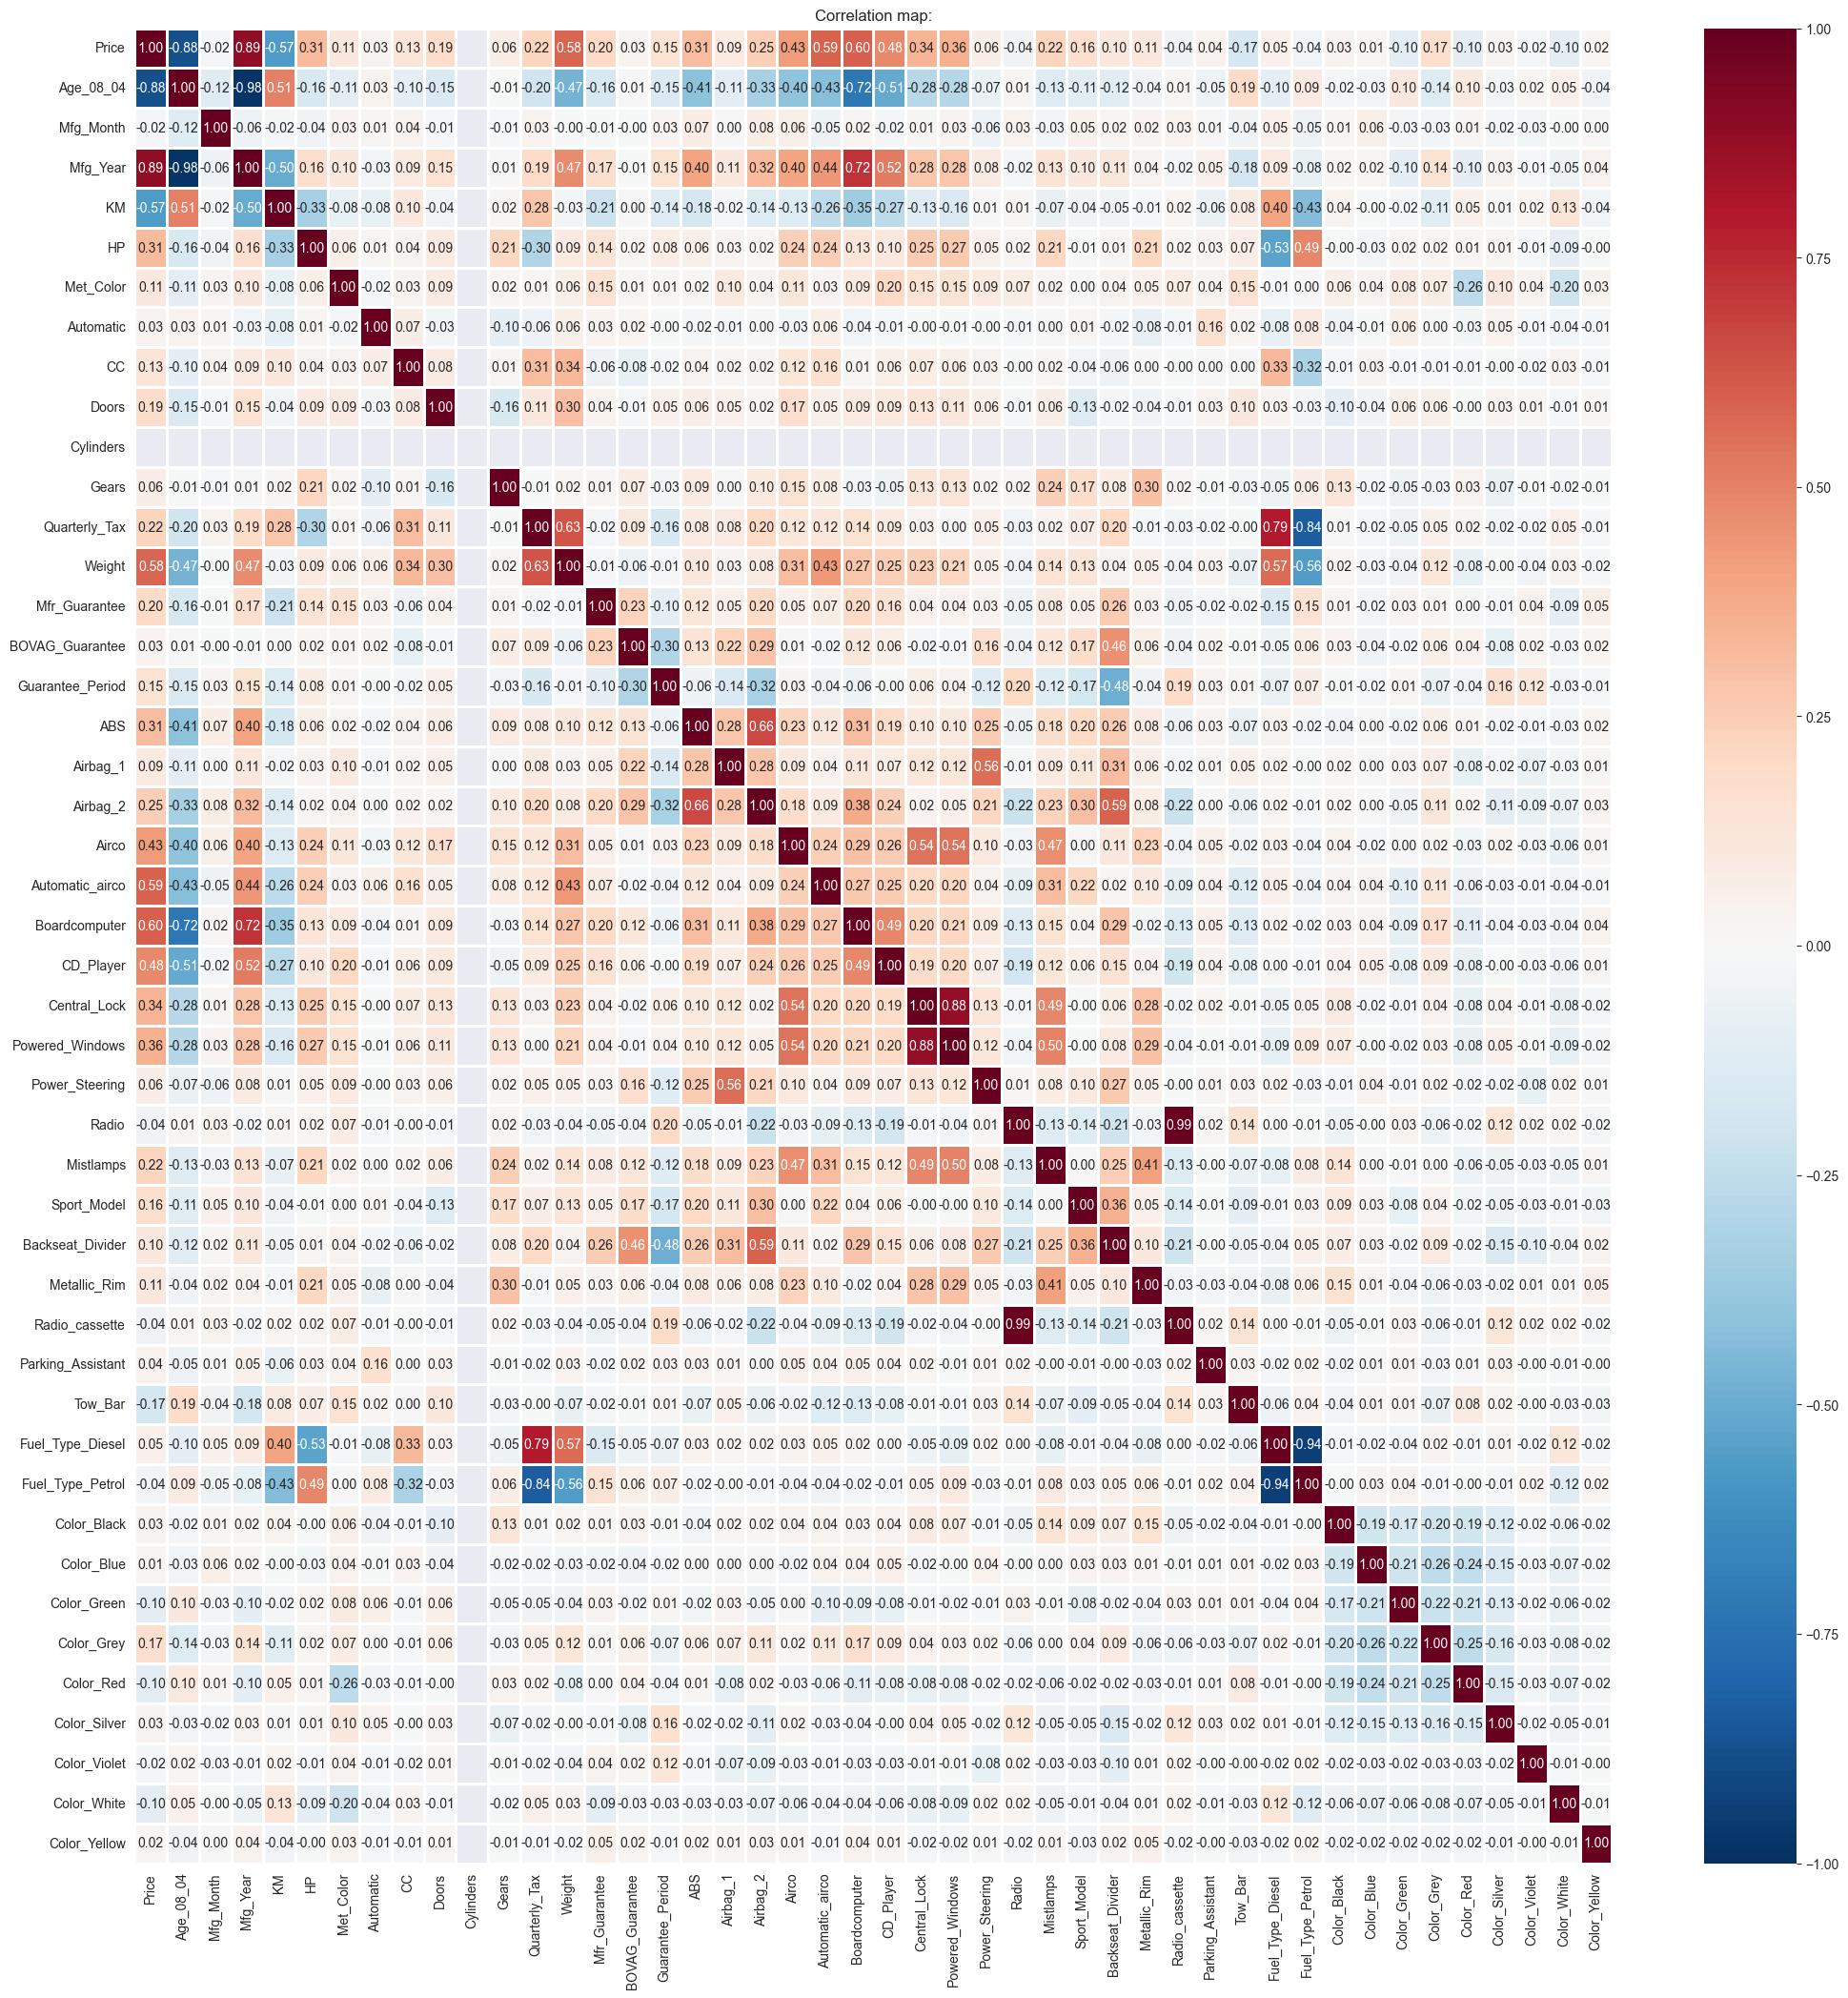

In [860]:
plt.figure(figsize=(25, 25))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='RdBu_r',   
    fmt='.2f',
    center=0,       
    linewidths=1,      
    vmin=-1, vmax=1    
)
plt.title('Correlation map:')
plt.show()

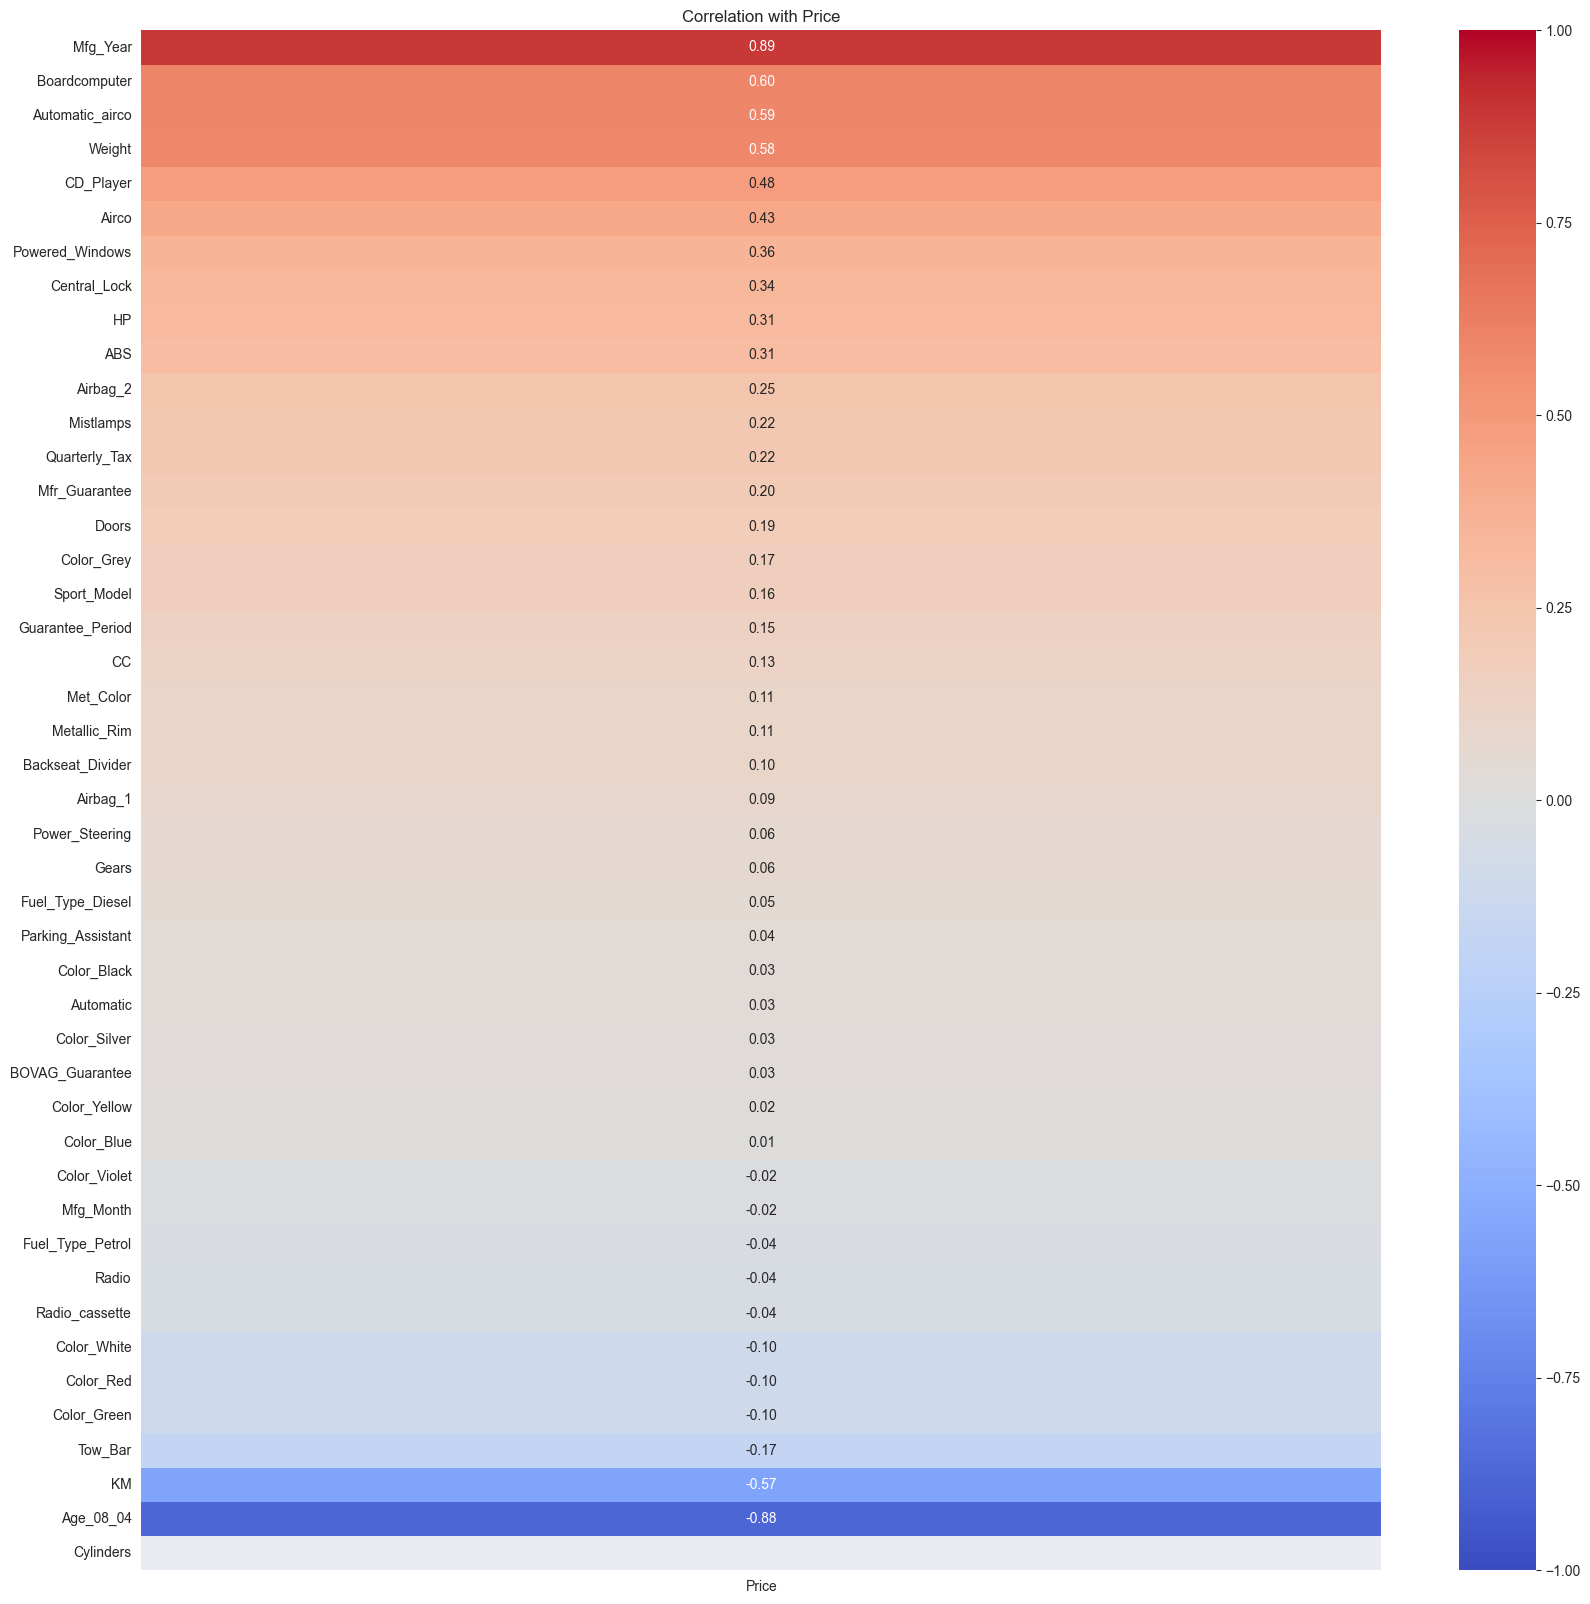

In [861]:
corr_with_price = df.select_dtypes(include=['number']).corr()['Price'].sort_values(ascending=False)

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_with_price.drop('Price').to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    cbar=True
)
plt.title('Correlation with Price')
plt.show()

Во время EDA я использовал стандартные методы его проведения: изучил структуру датасета методом info(), получил детальную информацию о средних значениях числовых признаков методом describe(), дополнительно вызвал методы для получения дисперсии, асимметрии и эксцесса. Также построил минимальный набор графиков для наблюдения выбросов признаков, их корреляции (тепловая карта) между собой и рассмотрел зависимость от цены категориальных признаков. Выбрал target переменную - Price.

Предобработкой данных являлось удаление заведомо ненужного признака Id, One-Hot Encoding категориальных признаков. Дальнейшая обработка будет описана ниже в выводе и проведена в п.3 представленного задания.

В ходе анализа было замечено, что опираться на сухие цифры из describe() или другие метрики (например, моменты распределения) не очень хорошо, так как они не всегда отражают истинную картину распределения, влияния признаков друг на друга и т.д. ОСОБЕННО на больших наборах данных. Гораздо лучше с этим справляются правильно выбранные графики (подобранные в зависимости от задачи). Пример в линейной регрессии - тепловая карта.

Вывод: 
- часть признаков практически никак не влияют на итоговую стоимость автомобиля, другие - неудобны для обработки линейной регрессией (переменные с нелинейной зависимостью);
- после анализа тепловой карты выявлены признаки, подозрительные на мультиколлинеарные. Их мы рассмотрим отдельно: построим scatterplot и boxplot графики и, если увидим линию - получим мультиколлинеарные признаки. Удалим тот, который МЕНЬШЕ вляет на Price;
- многие признаки (abs, radio и т.д.) отвечают за комплектацию автомобиля и по отдельности мало на что влияют (пример - radio). Однако влияние всё же оказывается, поэтому такие признаки будут пересчитаны в один - "Комплектация автомобиля" в виде некоего коэффициента (ниже будет описано конкретнее), это позволит (на бумаге) увеличить точность нашей модели. 
ВАЖНО: перед такого рода работой над признаками будет проведено разбиение на train и test, дабы не переобучить модель ненароком...;
- после всех преобразований признаков удалим те, которые слабо влияют на цену (коэф. кореляции меньше по модулю определённого числа (увидем его на графике после преобразование признаков. предположительно 0.2-0.3));

3. Feature Engineering:

Сперва разберёмся с "подозрительными" на мультиколлинеарные признаками.

Исходя из тепловой карты это четвёрки признаков:
- Quarterly_Tax, Weight, Fuel_type_Petrol и Fuel_Type_Diesel;
- KM, HP, Fuel_type_Petrol и Fuel_Type_Diesel;
Заметим, что и там, и там присутствуют булевы признаки типа автомобильного топлива.
А также пары:
- Mfg_Year и Age_08_04;
- Board_Computer и Mfg_Year/Age_08_04;

Строим scatterplot-ы:

In [862]:
fig = px.scatter(df, x='Weight', y='Quarterly_Tax', color='Fuel_Type_Diesel', 
                 title='Quarterly_Tax vs Weight (цвет = дизель)')
fig.show()

In [863]:
fig = px.scatter(df, x='KM', y='HP', color='Fuel_Type_Petrol',
                 title='KM vs HP (цвет = дизель)')
fig.show()

In [864]:
fig = px.scatter(df, x='Mfg_Year', y='Age_08_04')
fig.show()

In [865]:
fig = px.box(df, x='Mfg_Year', y='Boardcomputer')
fig.show()

Выявлено: явная линейная зависимость обнаружена только у 2-х признаков: Mfg_Year и Age_08_04. Последний удалим, так как он меньше влияет на Price по коэфф. корреляции Пирсона.

Более линейных зависимостей между признаками выявлено не было.

In [866]:
df.drop('Age_08_04', axis=1, inplace=True)

Перейдём к кодированию комплектации автомобиля. Для этого воспользуемся взвешенной суммой с весами (для test также посчитаем нужный нам признак комплектации автомобиля и удалим лишнее). Для этого сначала разобьём датасет на train и test:

In [867]:
X = df.drop('Price', axis=1, inplace=False)
Y = df['Price']

4. Разделение выборки:

Так уж вышло, что п.4 начинается внутри п.3)) прошу простить мою нелинейность повествования

In [868]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

А давайте попробуем обойтись без Ridge и Lasso, ручками преобразовав булевы признаки, а слабые удалив. А затем сравним с тем, что покажут нам модели с регуляризацией.
Тогда для начала сохраним копию нашего разбиения "до лучших времён":

In [869]:
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
Y_train_reg = Y_train.copy()
Y_test_reg = Y_test.copy()

Далее выделим признаки, которые будем объединять, в массив и объединим их с помощью взвешенной суммы в один признак (веса считаем ТОЛЬКО на train, в test веса не считаем, только применяем посчитанные ранее для train, дабы посчитать коэфф. комплектации по отношению к стоимости):

In [870]:
pca_features = [
    'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
    'Color_Black', 'Color_Blue', 'Color_Green', 'Color_Grey',
    'Color_Red', 'Color_Silver', 'Color_Violet', 'Color_White', 'Color_Yellow',
    'Met_Color', 'Automatic', 'Mfr_Guarantee', 'BOVAG_Guarantee',
    'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco',
    'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
    'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model',
    'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
    'Parking_Assistant', 'Tow_Bar'
]

train_df = X_train.copy()
train_df['Price'] = Y_train

test_df = X_test.copy()
test_df['Price'] = Y_test

weights = train_df[pca_features].corrwith(train_df['Price'])
weights = weights.clip(lower=0)

train_df['PCA_Features'] = train_df[pca_features].dot(weights)
train_df.drop(pca_features, axis=1, inplace=True)

test_df['PCA_Features'] = test_df[pca_features].dot(weights)
test_df.drop(pca_features, axis=1, inplace=True)

Получим такую выборку train исходного датасета:

In [871]:
train_df.head(3)

,Model,Mfg_Month,Mfg_Year,KM,HP,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Guarantee_Period,Price,PCA_Features
899,TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA 4/5-D...,7,1999,59295,86,1300,5,4,5,69,1035,3,9500,1.239625
881,TOYOTA Corolla 1.6 16V SEDAN LINEA TERRA 4/5-D...,1,1999,61568,110,1600,4,4,5,69,1035,3,9795,1.075689
310,TOYOTA Corolla 1.6 16V VVT I LIFTB SOL 4/5-Doors,5,2001,38653,110,1600,5,4,5,85,1080,3,12950,3.606886


И такую выборку test исходного датасета:

In [872]:
test_df.head(3)

,Model,Mfg_Month,Mfg_Year,KM,HP,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Guarantee_Period,Price,PCA_Features
594,TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-...,7,2000,22500,97,1400,3,4,5,69,1025,3,10800,2.042248
754,TOYOTA Corolla 1.6 16V HATCHB LINEA LUNA 2/3-D...,1,1999,80426,110,1600,3,4,5,85,1055,3,9950,2.077115
630,TOYOTA Corolla 2.0D XL Sedan 4/5-Doors,10,1999,130000,72,2000,4,4,5,185,1135,3,7500,0.519745


И, перед присваиванием новых значений X и Y выполним долгожданный "ручной Target Encoding":

In [873]:
mean_price = train_df.groupby('Model')['Price'].mean()

train_df['Model_encoded'] = train_df['Model'].map(mean_price)
test_df['Model_encoded'] = test_df['Model'].map(mean_price).fillna(train_df['Price'].mean())

train_df.drop('Model', axis=1, inplace=True)
test_df.drop('Model', axis=1, inplace=True)

А теперь вернёмся к X и Y:

In [874]:
X_train = train_df.drop('Price', axis=1)
Y_train = train_df['Price']

X_test = test_df.drop('Price', axis=1)
Y_test = test_df['Price']

И, наконец, после всего вышеописанного безумия для train_df и test_df построим тепловые карты корреляции с target переменной Price, дабы удалить оставшиеся "малозначимые признаки".

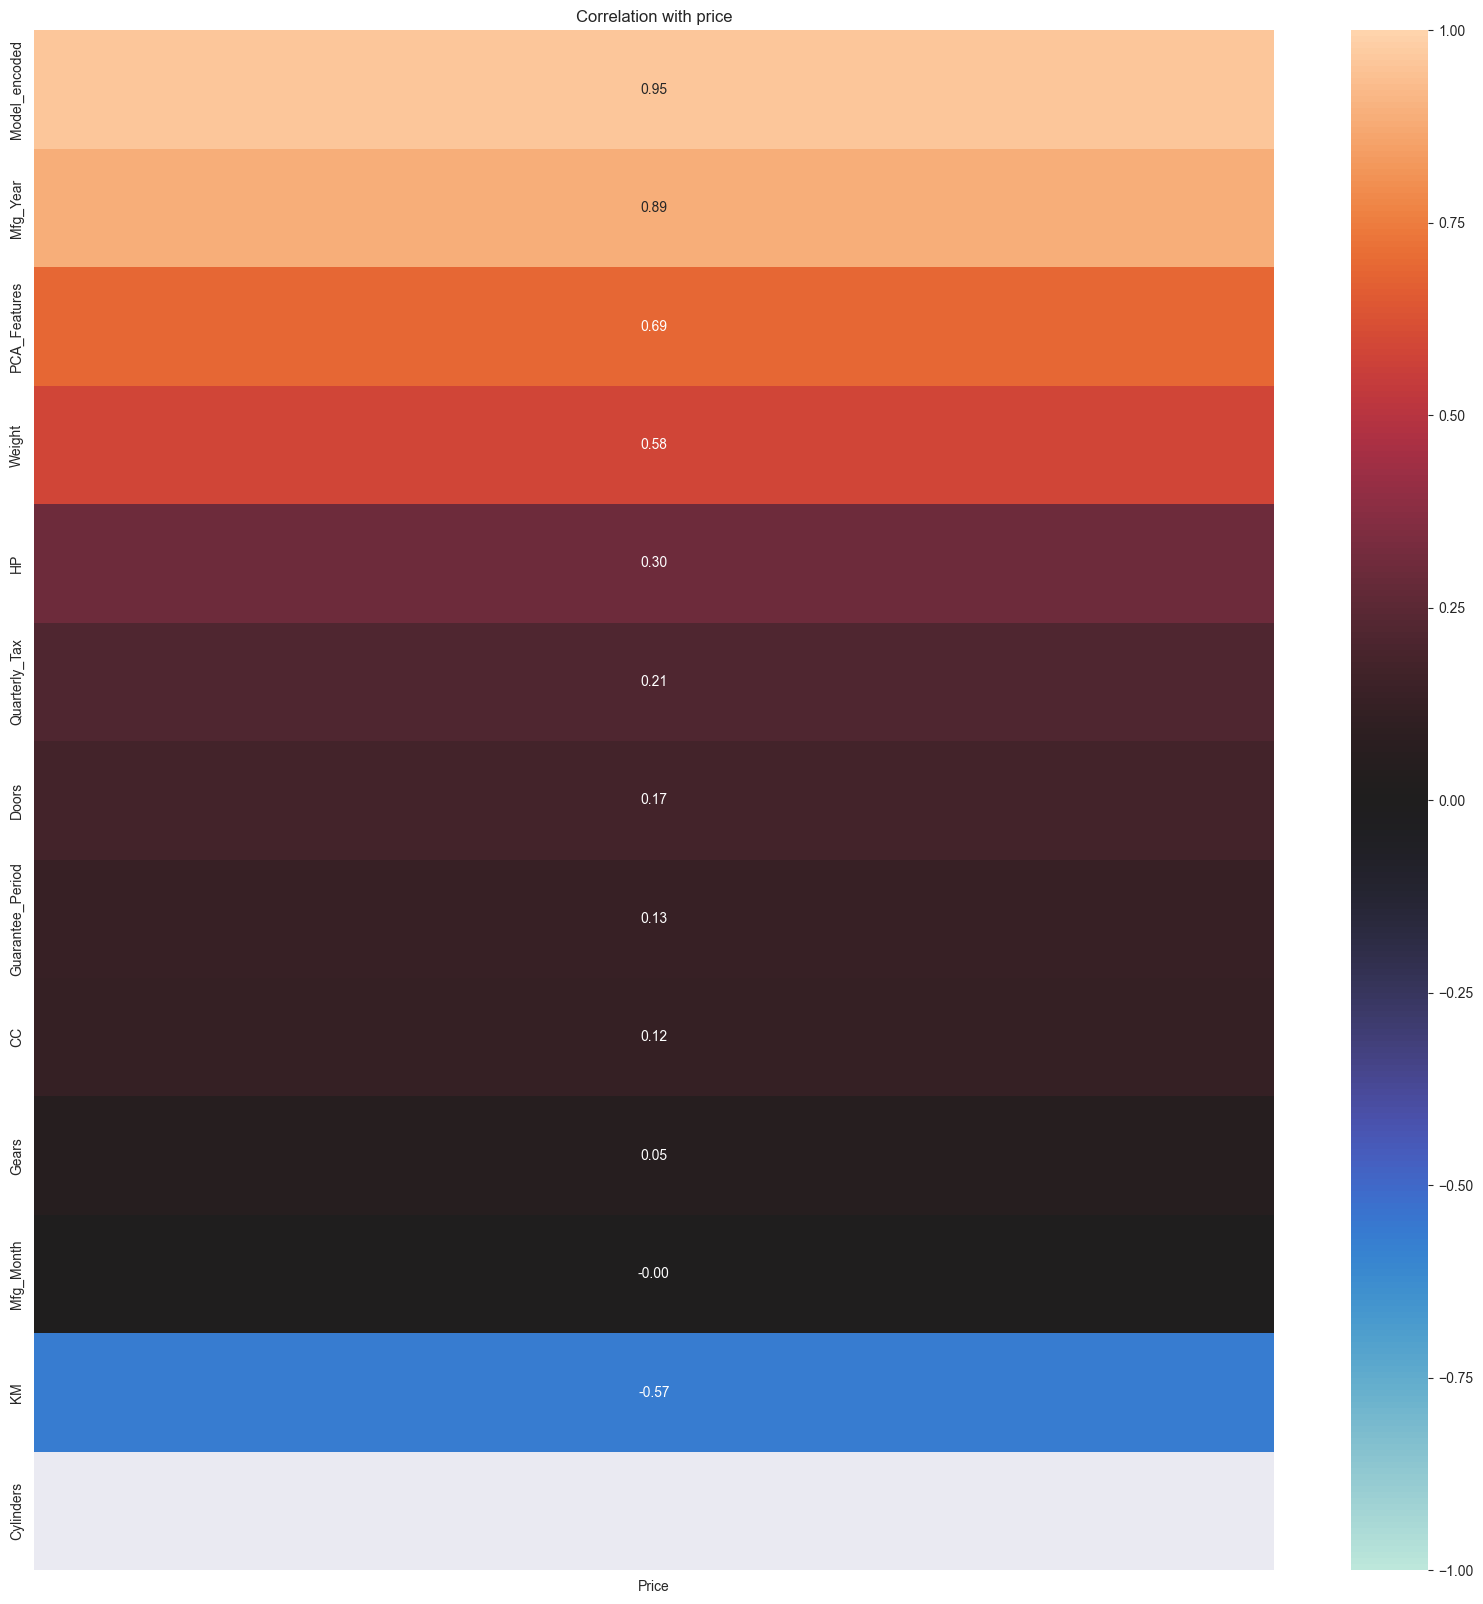

In [875]:
corr_with_price = train_df.corr()['Price'].sort_values(ascending=False)
plt.figure(figsize=(20,20))
fig = sns.heatmap(
    corr_with_price.drop('Price').to_frame(),
    annot=True,
    center=0, vmin=-1, vmax=1,
    cbar=True,
    fmt='.2f'
)
plt.title('Correlation with price')
plt.show()

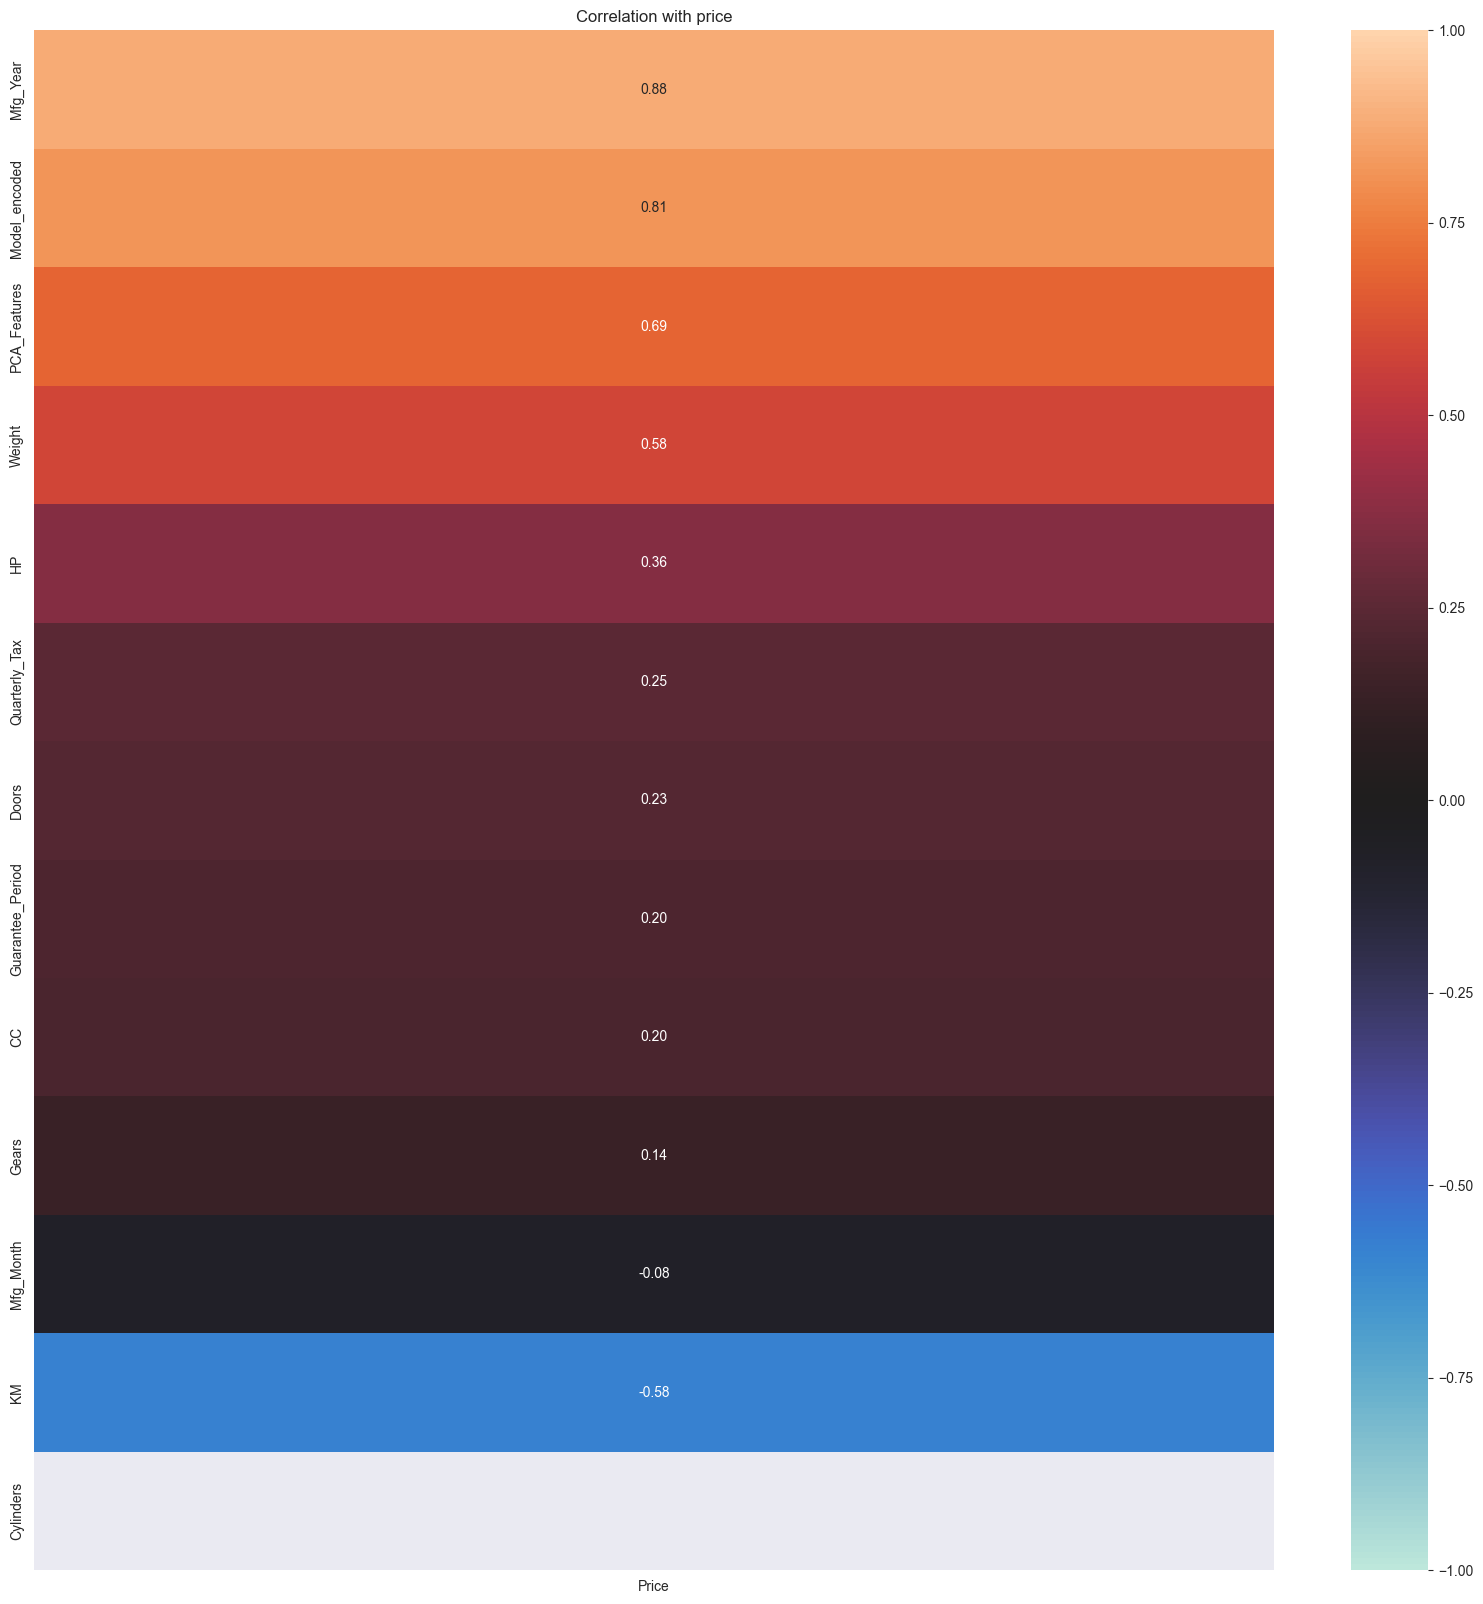

In [876]:
corr_with_price = test_df.corr()['Price'].sort_values(ascending=False)
plt.figure(figsize=(20,20))
fig = sns.heatmap(
    corr_with_price.drop('Price').to_frame(),
    annot=True,
    center=0, vmin=-1, vmax=1,
    cbar=True,
    fmt='.2f'
)
plt.title('Correlation with price')
plt.show()

Замечаем Богом забытые цилиндры и одинаковые малозначимые признаки в обеих выборках (коэфф. корреляции Пиросна по модулю меньше 0.3).
Удаляем их из обеих выборок:

In [877]:
features_to_del = ['Cylinders', 'Mfg_Month', 'Gears', 'CC', 'Guarantee_Period', 'Doors', 'Quarterly_Tax']

train_df.drop(features_to_del, axis=1, inplace=True)
test_df.drop(features_to_del, axis=1, inplace=True)
X_train.drop(features_to_del, axis=1, inplace=True)
X_test.drop(features_to_del, axis=1, inplace=True)

Посмотрим на итоговый вид данных:

In [878]:
print(train_df.head(2))
print(test_df.head(2))
print(X_train.head(2))
print(X_test.head(2))

     Mfg_Year     KM   HP  Weight  Price  PCA_Features  Model_encoded
899      1999  59295   86    1035   9500      1.239625    8434.516129
881      1999  61568  110    1035   9795      1.075689    8353.750000
     Mfg_Year     KM   HP  Weight  Price  PCA_Features  Model_encoded
594      2000  22500   97    1025  10800      2.042248   10407.857143
754      1999  80426  110    1055   9950      2.077115    8504.615385
     Mfg_Year     KM   HP  Weight  PCA_Features  Model_encoded
899      1999  59295   86    1035      1.239625    8434.516129
881      1999  61568  110    1035      1.075689    8353.750000
     Mfg_Year     KM   HP  Weight  PCA_Features  Model_encoded
594      2000  22500   97    1025      2.042248   10407.857143
754      1999  80426  110    1055      2.077115    8504.615385


А теперь сделаем Target Encoding, но оставим остальные признаки (кроме константного "Cylinders" и счётчика "Id") без изменений (регуляризация справится сама):

In [879]:
train_df_reg = X_train_reg.copy()
train_df_reg['Price'] = Y_train_reg

test_df_reg = X_test_reg.copy()
test_df_reg['Price'] = Y_test_reg

In [880]:
mean_price = train_df_reg.groupby('Model')['Price'].mean()

train_df_reg['Model_encoded'] = train_df_reg['Model'].map(mean_price)
test_df_reg['Model_encoded'] = test_df_reg['Model'].map(mean_price).fillna(train_df_reg['Price'].mean())

train_df_reg.drop('Model', axis=1, inplace=True)
test_df_reg.drop('Model', axis=1, inplace=True)

train_df_reg.drop('Cylinders', axis=1, inplace=True)
test_df_reg.drop('Cylinders', axis=1, inplace=True)

In [881]:
X_train_reg = train_df_reg.drop('Price', axis=1)
Y_train_reg = train_df_reg['Price']

X_test_reg = test_df_reg.drop('Price', axis=1)
Y_test_reg = test_df_reg['Price']

Тепловые карты для train и test:

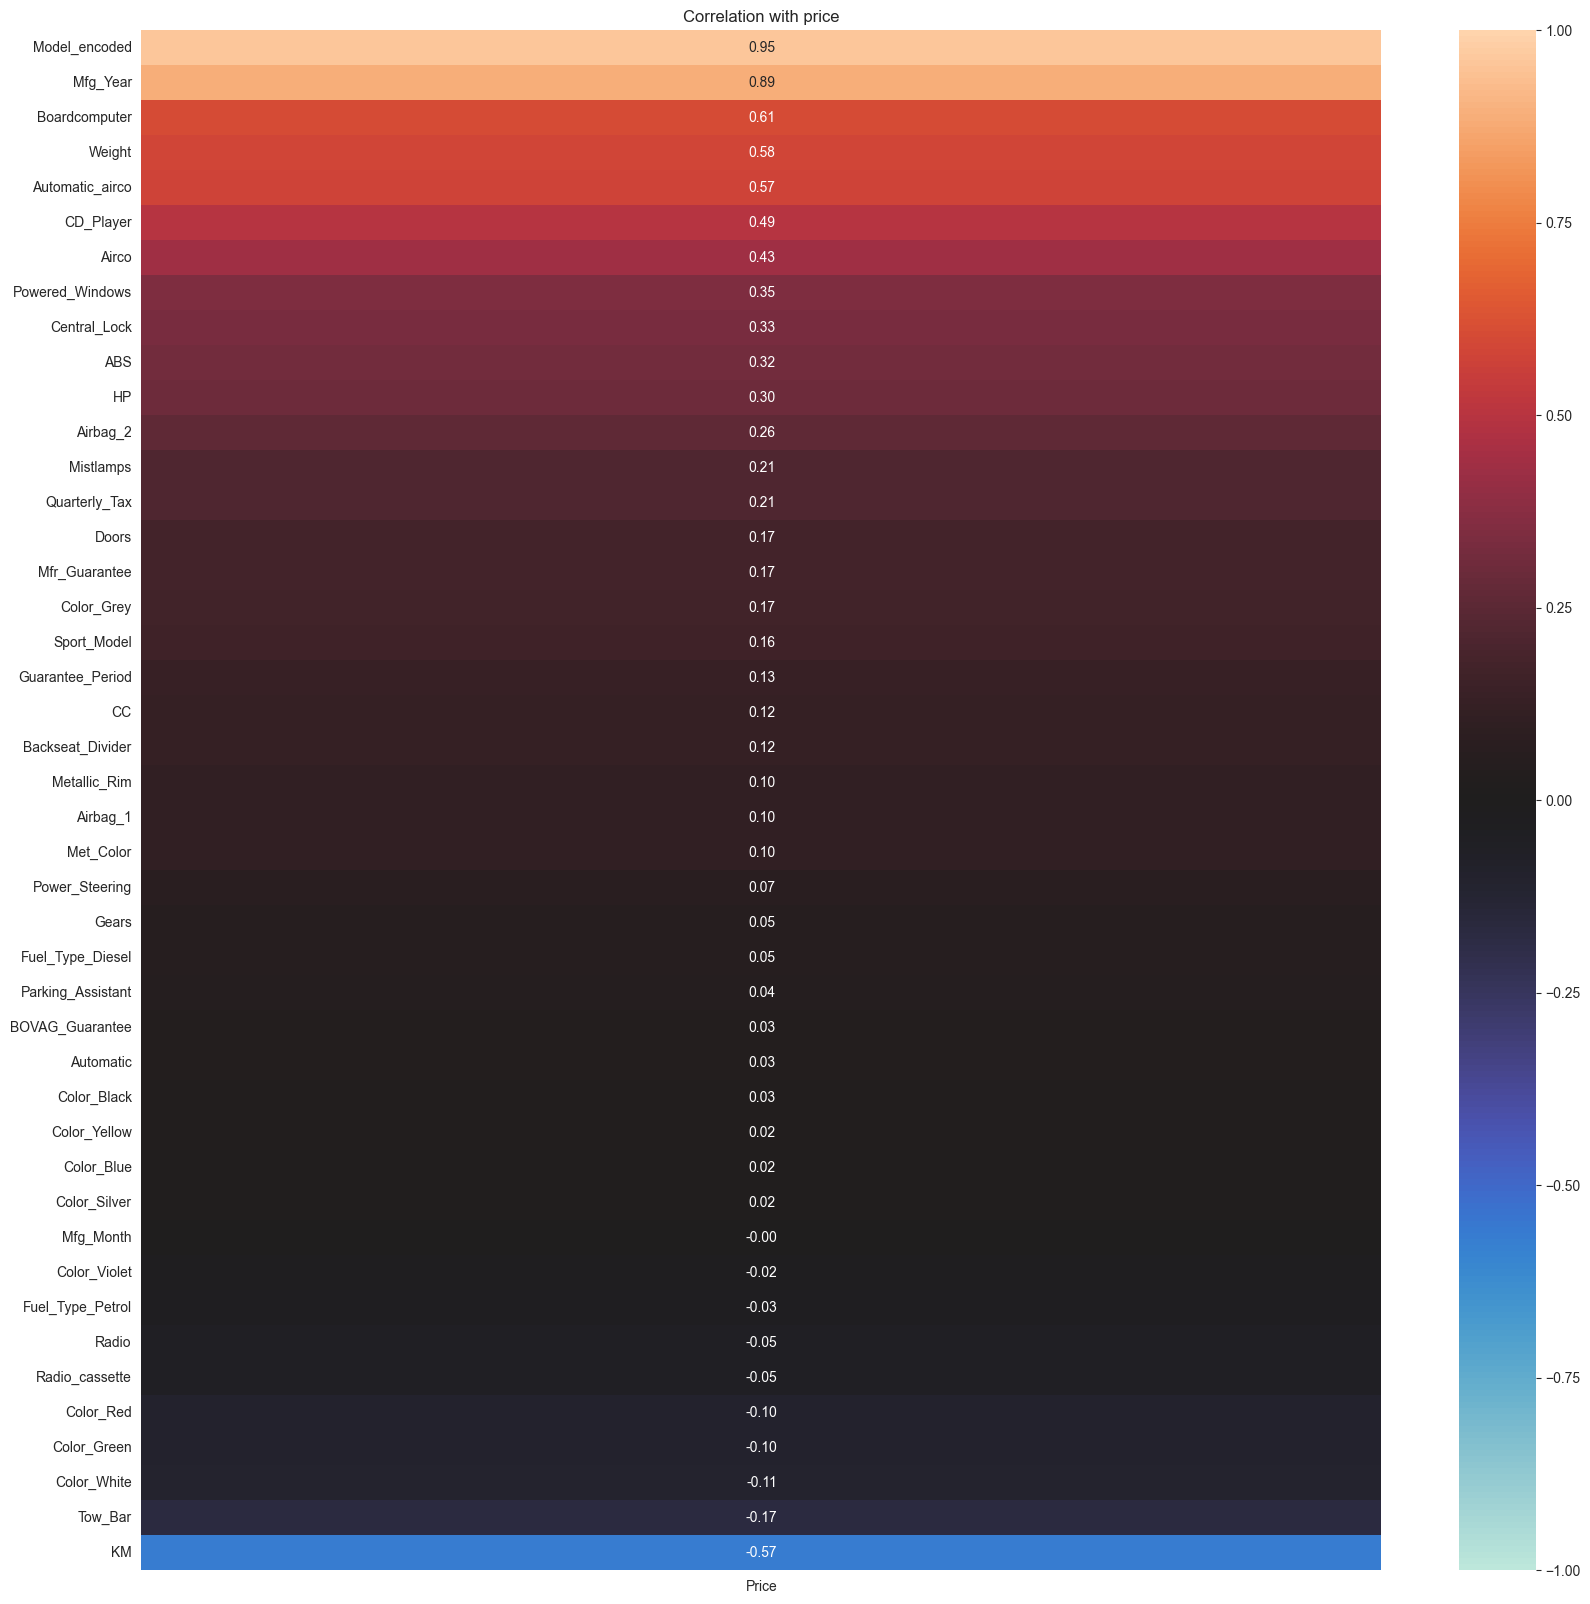

In [882]:
corr_with_price = train_df_reg.corr()['Price'].sort_values(ascending=False)
plt.figure(figsize=(20,20))
fig = sns.heatmap(
    corr_with_price.drop('Price').to_frame(),
    annot=True,
    center=0, vmin=-1, vmax=1,
    cbar=True,
    fmt='.2f'
)
plt.title('Correlation with price')
plt.show()

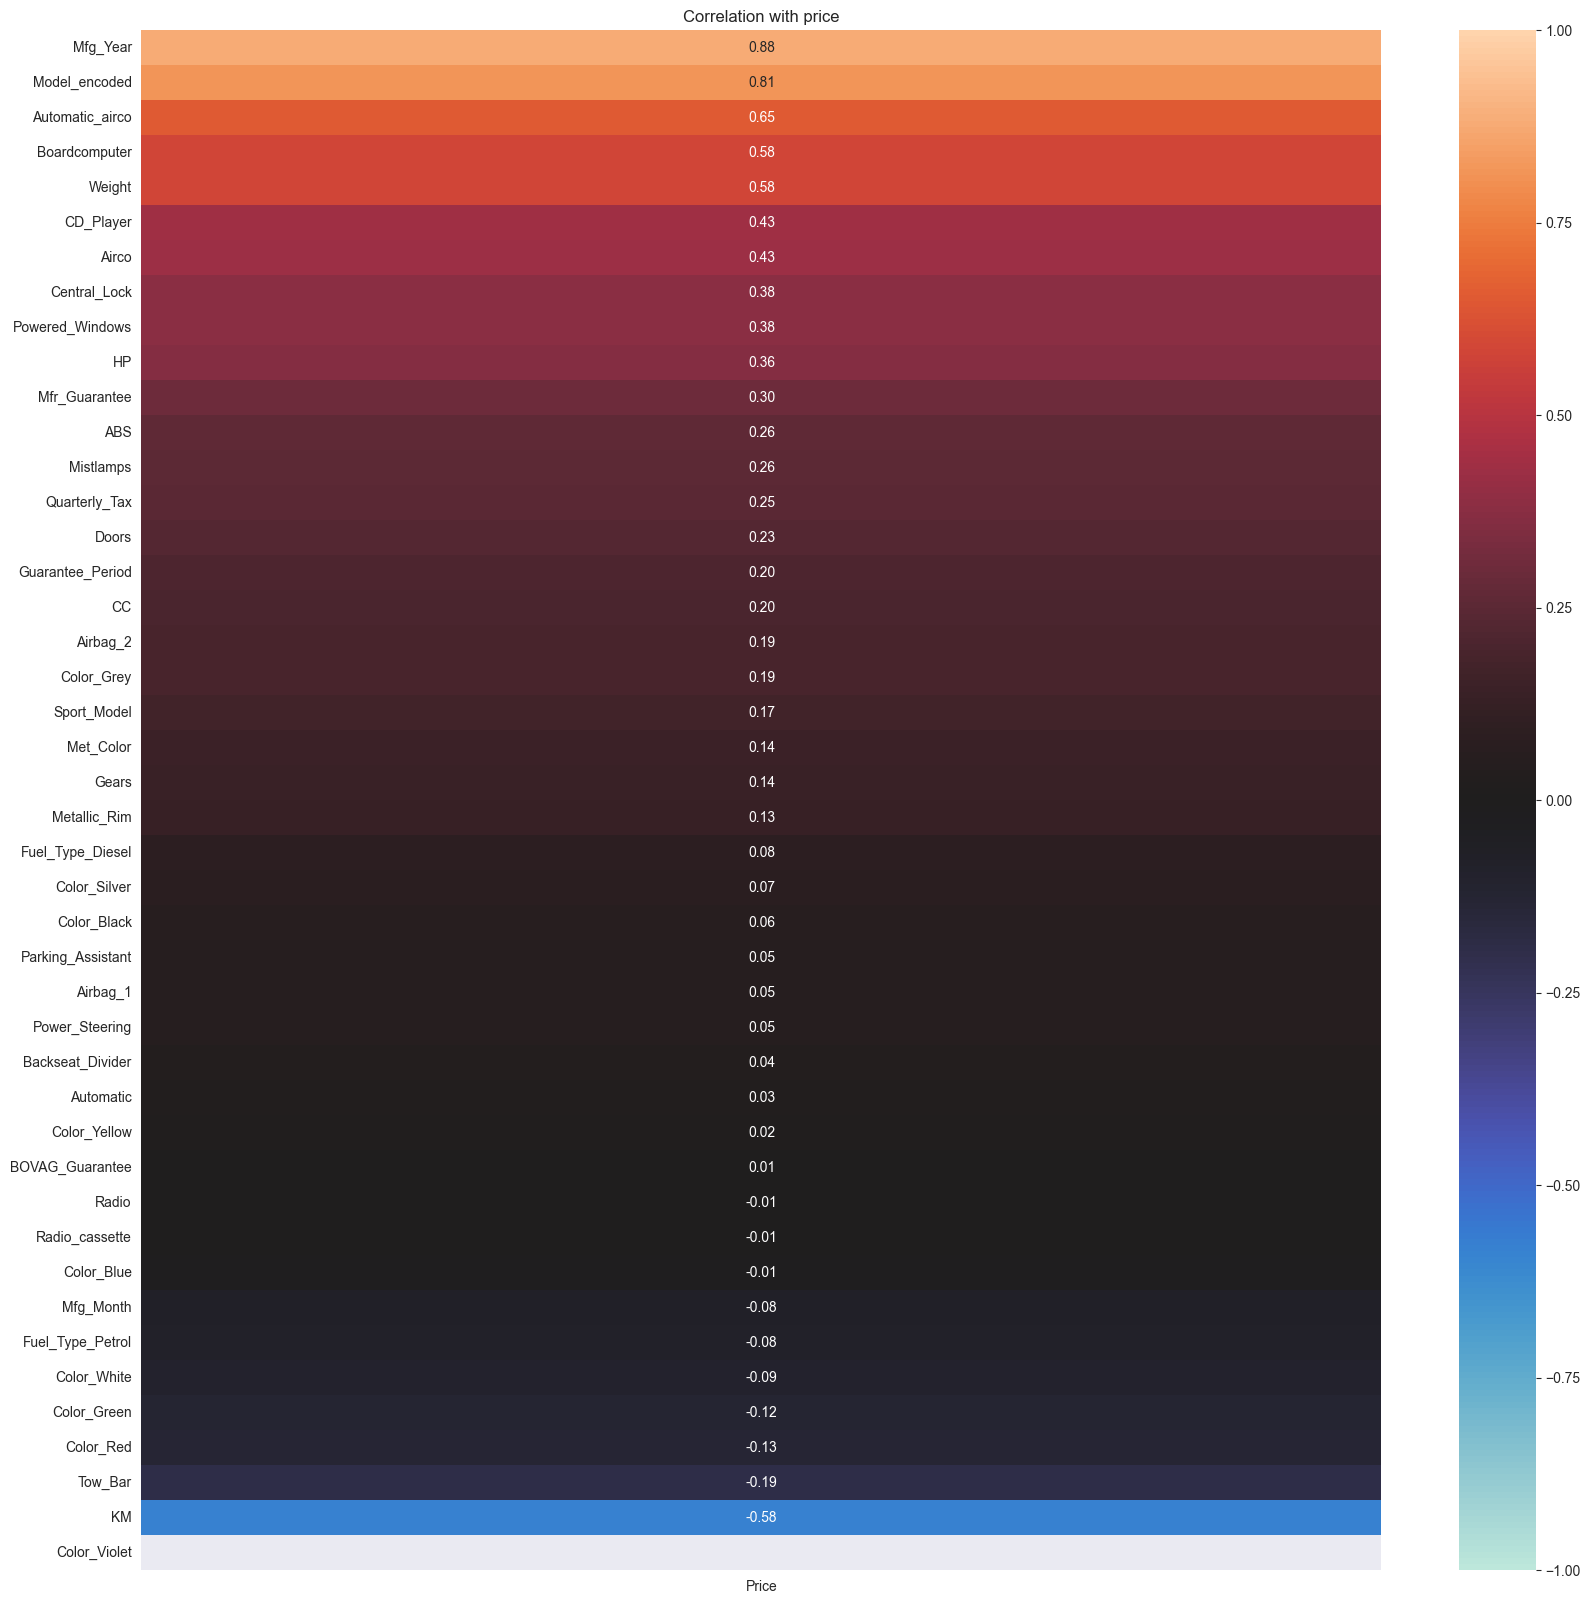

In [883]:
corr_with_price = test_df_reg.corr()['Price'].sort_values(ascending=False)
plt.figure(figsize=(20,20))
fig = sns.heatmap(
    corr_with_price.drop('Price').to_frame(),
    annot=True,
    center=0, vmin=-1, vmax=1,
    cbar=True,
    fmt='.2f'
)
plt.title('Correlation with price')
plt.show()

Удалим те, что по модулю меньше 0.15 по коэфф. корреляции Пирсона:

In [884]:
features_to_del = ["Guarantee_Period", "CC", "Color_Grey", "Backseat_Divider", "Metallic_Rim", "Airbag_1", "Met_Color", "Power_Steering", "Gears", "Fuel_Type_Diesel", "Parking_Assistant", "BOVAG_Guarantee", "Automatic", "Color_Black", "Color_Yellow", "Color_Blue", "Color_Silver", "Mfg_Month", "Color_Violet", "Fuel_Type_Petrol", "Radio", "Radio_cassette", "Color_Red", "Color_Green", "Color_White"]

train_df_reg.drop(features_to_del, axis=1, inplace=True)
test_df_reg.drop(features_to_del, axis=1, inplace=True)
X_train_reg.drop(features_to_del, axis=1, inplace=True)
X_test_reg.drop(features_to_del, axis=1, inplace=True)

Итоговый вид данных для последующей регуляризации:

In [885]:
print(train_df_reg.head(2))
print(test_df_reg.head(2))
print(X_train_reg.head(2))
print(X_test_reg.head(2))

     Mfg_Year     KM   HP  Doors  Quarterly_Tax  Weight  Mfr_Guarantee  ABS  \
899      1999  59295   86      5             69    1035              1    1   
881      1999  61568  110      4             69    1035              1    1   

     Airbag_2  Airco  Automatic_airco  Boardcomputer  CD_Player  Central_Lock  \
899         1      0                0              0          0             0   
881         1      0                0              0          0             0   

     Powered_Windows  Mistlamps  Sport_Model  Tow_Bar  Price  Model_encoded  
899                0          0            1        0   9500    8434.516129  
881                0          0            0        1   9795    8353.750000  
     Mfg_Year     KM   HP  Doors  Quarterly_Tax  Weight  Mfr_Guarantee  ABS  \
594      2000  22500   97      3             69    1025              0    1   
754      1999  80426  110      3             85    1055              1    1   

     Airbag_2  Airco  Automatic_airco  Boardco

Визуально всё прекрасно, а значит можно наконец переходить к выводам.

Выводы по Feature Engineering и разбиению на train/test:

В результате Feature Engineering-а я:

- разбил датасет на 2: датасет для модели, обученной без использования регуляризации, и датасет для обучения с использованием Ridge, Lasso и Elastic Net;
- закодировал категориальные признаки (цвет и тип топлива закодировал с помощью One-Hot Encoding, модель автомобиля - с помощью Target Encoding);
- подозрительные на мультиколлинеарные признаки рассмотрел детальнее и, выявив таковой, удалил за ненадобностью;
- преобразовал большое количество бинарных признаков, отвечающих за комплектацию автомобиля, в один коэффициент (исходя из тепловой карты, он является достаточно весомым, сильно влияя на стоимость автомобиля) для ПЕРВОГО датасета;
- из оставшихся удалил те, что имели коэфф. корреляции Пирсона с target переменной менее 0.3 для первого и 0.15 для второго датасетов;
- итого: получил 6 наиболее влиятельных признаков у первого и 19 (не много ли?) для второго датасетов, по которым и будут обучаться модели лин. регрессии;

В результате разбиения данных на train и test:

- получил несвязанные между собой данные, что позволило, например, провести Target Encoding и преобразование PCA_Features ТОЛЬКО на train выборке, никак на ломая test;
- !избежал Memory Leakage (утечка данных);
- впоследствии обработал test таким образом, чтобы признаки из test совпадали с признаками из train, что необходимо при Feature Engineering-е;

!ВАЖНО! - в ходе выполнения этого пункта была выявлена ошибка: часть Feature engineering-а (One-Hot Encoding) была выполнена до разбиения выборки, что является ошибкой (data leakage). One-Hot Encoding был выполнен до разделения данных, что не привело к искажению результата, так как тестовая выборка не содержала новых категорий. Однако в реальном проекте это было бы ошибкой, и следовало бы использовать OneHotEncoder из sklearn с fit на train и transform на test.

Вероятно, ошибка вызвана порядком пунктов в ДЗ...

5. Обучение моделей:

Сперва определимся, какие именно модели будем строить. Во-первых, проведём обучение модели без регуляризации. После чего, посмотрев на получившиеся результаты, сравним её с моделями, на которых мы использовали регуляризацию (рассмотрим и Ridge, и Lasso, и Elastic Net). Выберем 3 модели (2 лучшие с регуляризациями Ridge и Elastic Net и мою, смешнявую) и проверим их работоспособность на тестовых данных, сравним результаты, сделаем выводы.

Теперь, определившись с поставленной задачей, приступим к первому пункту: обучение линейной регрессии модели без регуляризации.

5.1. Обучение модели без регуляризации:

In [886]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, Y_train)

Y_train_pred = model.predict(X_train_scaled)
Y_test_pred = model.predict(X_test_scaled)

5.2. Обучение моделей с регуляризацией (Ridge, Lasso, Elastic Net):

In [887]:
scaler_reg= StandardScaler()
X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg)
X_test_scaled_reg = scaler_reg.transform(X_test_reg)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 
    'l1_ratio': [0, 0.5, 1]
}

anton = GridSearchCV(
    ElasticNet(random_state=42, max_iter=10000),
    param_grid,
    n_jobs=2,
    cv=5,
    scoring='neg_mean_absolute_error'
)
anton.fit(X_train_scaled_reg, Y_train_reg)

cv_results = pd.DataFrame(anton.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

In [888]:
cv_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
14,0.000908,0.000017,0.000324,0.000009,10.000,1.0,"{'alpha': 10, 'l1_ratio': 1}",-653.104116,-672.706742,-644.459623,-615.366864,-677.944085,-652.716286,22.357828,1
11,0.000867,0.000023,0.000329,0.000049,1.000,1.0,"{'alpha': 1, 'l1_ratio': 1}",-654.994527,-678.782296,-644.045957,-618.649912,-674.970550,-654.288648,21.923551,2
8,0.000928,0.000023,0.000296,0.000005,0.100,1.0,"{'alpha': 0.1, 'l1_ratio': 1}",-655.633198,-679.898945,-644.045392,-619.294066,-674.712002,-654.716721,21.924586,3
0,0.049604,0.003207,0.000560,0.000023,0.001,0.0,"{'alpha': 0.001, 'l1_ratio': 0}",-655.686544,-679.319185,-643.776718,-619.911741,-674.904527,-654.719743,21.655667,4
1,0.001312,0.000229,0.000329,0.000054,0.001,0.5,"{'alpha': 0.001, 'l1_ratio': 0.5}",-655.695239,-679.666506,-643.907521,-619.645911,-674.794474,-654.741930,21.786981,5


In [889]:
cv_results.tail(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,0.045343,0.004150,0.000510,0.000060,100.0,0.0,"{'alpha': 100, 'l1_ratio': 0}",-2290.346106,-2813.225027,-2443.662963,-2585.758012,-2528.902807,-2532.378983,172.154785,19
19,0.000836,0.000079,0.000321,0.000020,1000.0,0.5,"{'alpha': 1000, 'l1_ratio': 0.5}",-2374.912432,-2911.872517,-2536.465984,-2679.290716,-2619.708772,-2624.450084,176.438018,20
18,0.043818,0.002763,0.000545,0.000054,1000.0,0.0,"{'alpha': 1000, 'l1_ratio': 0}",-2380.145675,-2917.514231,-2542.198727,-2684.697783,-2625.191710,-2629.949625,176.530810,21


Посмотрим на все модели с помощью графика scatterplot:

In [890]:
fig = px.scatter(
    cv_results, 
    x='rank_test_score',
    y='std_test_score',
    color='mean_fit_time'
)
fig.show()

Так как std_test_score не сильно отличается от модели к модели, просто возьмём 3 лучшие модели по заданной метрике MAE (в данном случае это 2-я, 4-я и 5-я модели по rank_test_score):

In [891]:
model_reg_lasso = ElasticNet(l1_ratio=1, alpha=1)
model_reg_ridge = ElasticNet(l1_ratio=0, alpha=0.001)
model_reg_elastic_net = ElasticNet(l1_ratio=0.5, alpha=0.001)

model_reg_lasso.fit(X_train_scaled_reg, Y_train_reg)
model_reg_ridge.fit(X_train_scaled_reg, Y_train_reg)
model_reg_elastic_net.fit(X_train_scaled_reg, Y_train_reg)

d:\BSU_FAMCS\course_2\semester_4\ML_Course\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.280e+08, tolerance: 1.503e+06
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Обучение моделей происходило следующим образом:
- Была выбрана модель, испытавшая на себе все чудеса моего неумения проводить качественный feature engineering, так ещё и без регуляризации обучена она была;
- Отчание от неудовлетворительного результата привело меня к создания ещё 3 моделей (с регуляризацией Ridge, Lasso и даже Elastic Net);
- Далее был использован GridSearchCV для подбора α и регуляризации, после - выбраны 3 лучшие модели по метрике MAE (одна с Lasso, одна с Ridge и одна с Elastic Net регуляризациями); 
- Теперь сделано всё, чтобы переходить к проверке результата, разве что ещё обратим внимание на время обучение;

Отметим, что модель с Ridge регуляризацией в среднем обучалась в 5-10 раз медленнее, чем остальные модели. Особенно хорошо это видно на графике, где 7 из 21 точек жёлтые, что и значит большую длительность обучения (как нетрудно догадаться, все эти точки - модели, обучавшиеся с использованием Ridge регуляризации).

Заметим также, что модель с Elastic Net регуляризацией модели обучались примерно с той же скоростью, что и модели с Lasso регуляризацией. 

Подбор гиперпараметра α на время обучения модели, к великому моему удивлению, существенного влияния не оказал.

6. Оценка качества и сравнение моделей:

In [892]:
# напишем функцию для MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

И посмотрим получившиеся метрики:

In [893]:
print("=== Метрики модели без регуляризации===")
print(f"Train R²: {r2_score(Y_train, Y_train_pred):.4f}")
print(f"Test  R²: {r2_score(Y_test, Y_test_pred):.4f}")
print(f"Train MAE: {mean_absolute_error(Y_train, Y_train_pred):.0f}")
print(f"Test  MAE: {mean_absolute_error(Y_test, Y_test_pred):.0f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(Y_train, Y_train_pred)):.0f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(Y_test, Y_test_pred)):.0f}")
print(f"Train MAPE: {mape(Y_train, Y_train_pred):.2f}%")
print(f"Test  MAPE: {mape(Y_test, Y_test_pred):.2f}%")
print(f"Train MSE: {mean_squared_error(Y_train, Y_train_pred)}")
print(f"Test MSE: {mean_squared_error(Y_test, Y_test_pred)}")
print("\n=== Метрики модели LASSO1 ===")
print(f"Train R²: {r2_score(Y_train_reg, model_reg_lasso.predict(X_train_scaled_reg)):.4f}")
print(f"Test  R²: {r2_score(Y_test_reg, model_reg_lasso.predict(X_test_scaled_reg)):.4f}")
print(f"Train MAE: {mean_absolute_error(Y_train_reg, model_reg_lasso.predict(X_train_scaled_reg)):.0f}")
print(f"Test  MAE: {mean_absolute_error(Y_test_reg, model_reg_lasso.predict(X_test_scaled_reg)):.0f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(Y_train_reg, model_reg_lasso.predict(X_train_scaled_reg))):.0f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(Y_test_reg, model_reg_lasso.predict(X_test_scaled_reg))):.0f}")
print(f"Train MAPE: {mape(Y_train_reg, model_reg_lasso.predict(X_train_scaled_reg)):.2f}%")
print(f"Test  MAPE: {mape(Y_test_reg, model_reg_lasso.predict(X_test_scaled_reg)):.2f}%")
print(f"Train MSE: {mean_squared_error(Y_train_reg, model_reg_lasso.predict(X_train_scaled_reg)):.0f}")
print(f"Test MSE: {mean_squared_error(Y_test_reg, model_reg_lasso.predict(X_test_scaled_reg)):.0f}")
print("\n=== Метрики модели RIDGE ===")
print(f"Train R²: {r2_score(Y_train_reg, model_reg_ridge.predict(X_train_scaled_reg)):.4f}")
print(f"Test  R²: {r2_score(Y_test_reg, model_reg_ridge.predict(X_test_scaled_reg)):.4f}")
print(f"Train MAE: {mean_absolute_error(Y_train_reg, model_reg_ridge.predict(X_train_scaled_reg)):.0f}")
print(f"Test  MAE: {mean_absolute_error(Y_test_reg, model_reg_ridge.predict(X_test_scaled_reg)):.0f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(Y_train_reg, model_reg_ridge.predict(X_train_scaled_reg))):.0f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(Y_test_reg, model_reg_ridge.predict(X_test_scaled_reg))):.0f}")
print(f"Train MAPE: {mape(Y_train_reg, model_reg_ridge.predict(X_train_scaled_reg)):.2f}%")
print(f"Test  MAPE: {mape(Y_test_reg, model_reg_ridge.predict(X_test_scaled_reg)):.2f}%")
print(f"Train MSE: {mean_squared_error(Y_train_reg, model_reg_ridge.predict(X_train_scaled_reg)):.0f}")
print(f"Test MSE: {mean_squared_error(Y_test_reg, model_reg_ridge.predict(X_test_scaled_reg)):.0f}")
print("\n=== Метрики модели ELASTIC NET (50/50) ===")
print(f"Train R²: {r2_score(Y_train_reg, model_reg_elastic_net.predict(X_train_scaled_reg)):.4f}")
print(f"Test  R²: {r2_score(Y_test_reg, model_reg_elastic_net.predict(X_test_scaled_reg)):.4f}")
print(f"Train MAE: {mean_absolute_error(Y_train_reg, model_reg_elastic_net.predict(X_train_scaled_reg)):.0f}")
print(f"Test  MAE: {mean_absolute_error(Y_test_reg, model_reg_elastic_net.predict(X_test_scaled_reg)):.0f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(Y_train_reg, model_reg_elastic_net.predict(X_train_scaled_reg))):.0f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(Y_test_reg, model_reg_elastic_net.predict(X_test_scaled_reg))):.0f}")
print(f"Train MAPE: {mape(Y_train_reg, model_reg_elastic_net.predict(X_train_scaled_reg)):.2f}%")
print(f"Test  MAPE: {mape(Y_test_reg, model_reg_elastic_net.predict(X_test_scaled_reg)):.2f}%")
print(f"Train MSE: {mean_squared_error(Y_train_reg, model_reg_elastic_net.predict(X_train_scaled_reg)):.0f}")
print(f"Test MSE: {mean_squared_error(Y_test_reg, model_reg_elastic_net.predict(X_test_scaled_reg)):.0f}")

=== Метрики модели без регуляризации===
Train R²: 0.9364
Test  R²: 0.8174
Train MAE: 689
Test  MAE: 974
Train RMSE: 913
Test  RMSE: 1561
Train MAPE: 6.97%
Test  MAPE: 9.51%
Train MSE: 833182.5474682917
Test MSE: 2435780.624223421

=== Метрики модели LASSO1 ===
Train R²: 0.9435
Test  R²: 0.8386
Train MAE: 641
Test  MAE: 904
Train RMSE: 860
Test  RMSE: 1467
Train MAPE: 6.49%
Test  MAPE: 8.86%
Train MSE: 739486
Test MSE: 2153391

=== Метрики модели RIDGE ===
Train R²: 0.9435
Test  R²: 0.8396
Train MAE: 641
Test  MAE: 903
Train RMSE: 860
Test  RMSE: 1463
Train MAPE: 6.49%
Test  MAPE: 8.85%
Train MSE: 739466
Test MSE: 2139857

=== Метрики модели ELASTIC NET (50/50) ===
Train R²: 0.9435
Test  R²: 0.8392
Train MAE: 641
Test  MAE: 904
Train RMSE: 860
Test  RMSE: 1465
Train MAPE: 6.49%
Test  MAPE: 8.85%
Train MSE: 739449
Test MSE: 2145127


Выводы:
- Успешно обучено 4 модели: без регуляризации, с Lasso, Ridge и Elastic Net регуляризациями;
- Все модели показали примерно одинаковый результат, разве что модель без регуляризации немного уступила по всем метрикам своим коллегам по несчастью;
- Для предсказания была выбрана метрика MAE. Причина - логичнее всего при предсказывании стоимости автомобиля смотреть именно на отклонение от истинной стоимости. GridSearchCV для перебора всевозможных вариантов наиболее важной метрики не использовался;
- Метрики считались и на train, и на test выборках. Причина: увидеть, переобучились ли модели и, если да, насколько сильно. Результат мы можем увидеть выше: модели действительно немного переобучились. И, если при обучении модели без регуляризации я предполагал, что всё дело в некачественном feature engineering-е, то после обучения моделей с регуляризацией вопросов стало больше, ибо переобучение никуда не делось. Возможно, полученные значения выше являются абсолютно нормальными и нет никакого переобучения. Однако, вероятнее всего, я просто не смог провести качественный feature engineering. В любом случае, если переобучение и есть, то оно некритично и для новых данных модель даёт достаточно точный прогноз стоимости;
- Результат: 
- - MAPE - 8.85% (test выборка). Более чем удовлетворительный результат для предсказания стоимости автомобиля. Снимаю шляпу перед теми, кто сможет сделать сильно лучше;
- - R² - 0.83 (test выборка). Вероятно, можно и лучше, однако главной целью ставилось минимизация MAE, так ещё и непонятно откуда взявшееся небольшое переобучение модели немного спутало карты;

Надеюсь, кто-то когда-то всё это хотя бы пролистает...)